In [1]:
import duckdb
con = duckdb.connect('duckdb.duckdb')
# con.sql("SHOW TABLES").show()
df_schema = con.execute("DESCRIBE cleaned_data").df()

import pandas as pd
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(df_schema)
con.close()

         column_name column_type null   key default extra
0               Time   TIMESTAMP  YES  None    None  None
1              Cycle      BIGINT  YES  None    None  None
2              Value      DOUBLE  YES  None    None  None
3             Signal     VARCHAR  YES  None    None  None
4               Path     VARCHAR  YES  None    None  None
5     SamplingPeriod      DOUBLE  YES  None    None  None
6         Value_Type     VARCHAR  YES  None    None  None
7         DataOrigin     VARCHAR  YES  None    None  None
8               Unit     VARCHAR  YES  None    None  None
9          Groupname     VARCHAR  YES  None    None  None
10       Description     VARCHAR  YES  None    None  None
11  Nc_variable_name     VARCHAR  YES  None    None  None
12              Axis     VARCHAR  YES  None    None  None
13  Duration_Seconds      DOUBLE  YES  None    None  None
14          WCS_Y_mm      DOUBLE  YES  None    None  None
15               Nut     INTEGER  YES  None    None  None
16            

In [16]:
import duckdb
con = duckdb.connect('DB.duckdb')
# con.sql("SHOW TABLES").show()
df_schema = con.execute("DESCRIBE my_table").df()
import pandas as pd
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(df_schema)
con.close()

                  column_name   column_type null   key default extra
0                        Time  TIMESTAMP_NS  YES  None    None  None
1            Duration_Seconds        DOUBLE  YES  None    None  None
2                      Signal       VARCHAR  YES  None    None  None
3                  DataOrigin       VARCHAR  YES  None    None  None
4                       Value        DOUBLE  YES  None    None  None
5                        Unit       VARCHAR  YES  None    None  None
6                Value_String       VARCHAR  YES  None    None  None
7                 Description       VARCHAR  YES  None    None  None
8                   Groupname       VARCHAR  YES  None    None  None
9          HFBlockEvent_GCode       VARCHAR  YES  None    None  None
10             SamplingPeriod        DOUBLE  YES  None    None  None
11                       Axis       VARCHAR  YES  None    None  None
12                       Path       VARCHAR  YES  None    None  None
13                 Value_Type     


--- Analyzing Proportions for: Signal ---
              Signal  legacy_count  legacy_pct  new_count  new_pct  pct_diff
                   0      36900400       36.95          0     0.00     36.95
           dataA1CH1             0        0.00     853523    13.13     13.13
           dataA1CH2             0        0.00     853523    13.13     13.13
           dataA2CH1             0        0.00     853523    13.13     13.13
     ToolOrientation       5190705        5.20          0     0.00      5.20
         WCSPosition       5190705        5.20          0     0.00      5.20
        CTRL_DIFF2|6        576745        0.58      43228     0.67      0.09
           CURRENT|3        576745        0.58      43228     0.67      0.09
        TORQUE_FFW|2        576745        0.58      43228     0.67      0.09
          ENC2_POS|2        576745        0.58      43228     0.67      0.09
        CMD_SPEED|12        576745        0.58      43228     0.67      0.09
           VEL_FFW|2        57674

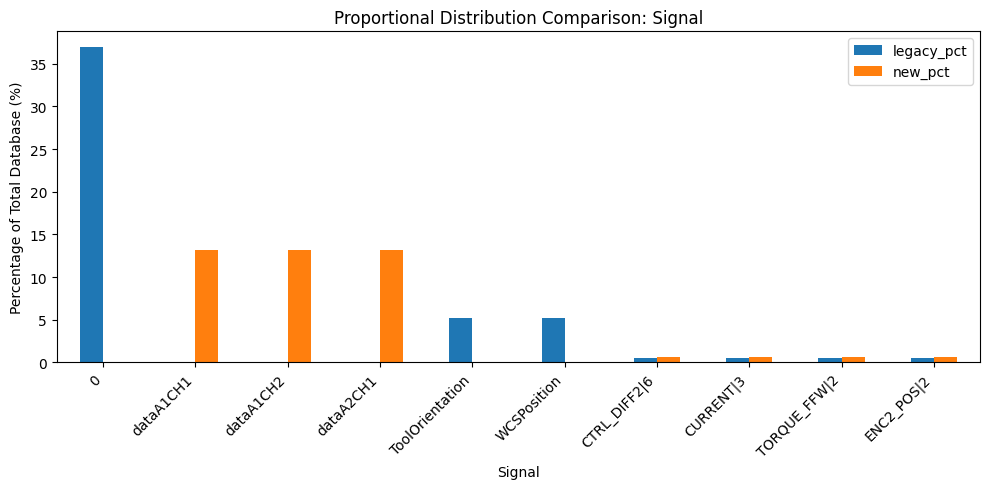


--- Analyzing Proportions for: DataOrigin ---
  DataOrigin  legacy_count  legacy_pct  new_count  new_pct  pct_diff
  ET200_Data             0        0.00    2560569    39.40     39.40
Oscilloscope      36900400       36.95          0     0.00     36.95
     HF_Data      62865205       62.95    3933748    60.52      2.43
     LF_Data         93053        0.09       5282     0.08      0.01


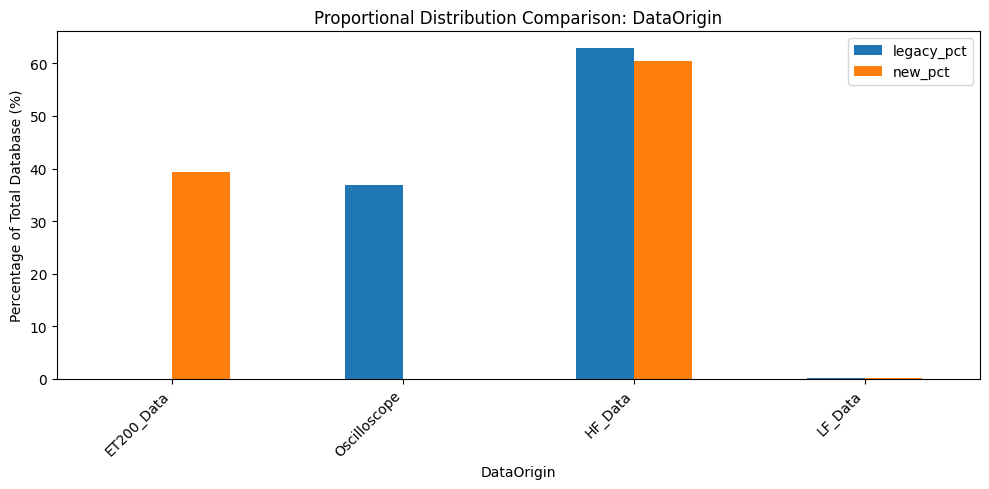

In [3]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

con = duckdb.connect('duckdb.duckdb')
con.execute("ATTACH 'DB.duckdb' AS legacy_db;")

def analyze_proportions(column_name):
    print(f"\n--- Analyzing Proportions for: {column_name} ---")
    
    query = f"""
    WITH legacy_counts AS (
        SELECT {column_name}, COUNT(*) as cnt
        FROM legacy_db.my_table
        GROUP BY {column_name}
    ),
    new_counts AS (
        SELECT {column_name}, COUNT(*) as cnt
        FROM main.cleaned_data
        GROUP BY {column_name}
    ),
    legacy_total AS (SELECT COUNT(*) as total FROM legacy_db.my_table),
    new_total AS (SELECT COUNT(*) as total FROM main.cleaned_data)
    
    SELECT 
        COALESCE(l.{column_name}, n.{column_name}) AS {column_name},
        l.cnt AS legacy_count,
        ROUND((l.cnt * 100.0 / (SELECT total FROM legacy_total)), 2) AS legacy_pct,
        n.cnt AS new_count,
        ROUND((n.cnt * 100.0 / (SELECT total FROM new_total)), 2) AS new_pct
    FROM legacy_counts l
    FULL OUTER JOIN new_counts n ON l.{column_name} = n.{column_name};
    """
    
    df = con.execute(query).df()
    
    df.fillna(0, inplace=True)
    
    df['pct_diff'] = (df['new_pct'] - df['legacy_pct']).abs()
    
    df = df.sort_values(by='pct_diff', ascending=False)
    print(df.to_string(index=False))
    
    top_plot = df.head(10)
    ax = top_plot.plot(x=column_name, y=['legacy_pct', 'new_pct'], kind='bar', figsize=(10, 5))
    plt.title(f'Proportional Distribution Comparison: {column_name}')
    plt.ylabel('Percentage of Total Database (%)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
    return df

signal_df = analyze_proportions('Signal')
origin_df = analyze_proportions('DataOrigin')

In [19]:
print("\n--- Verifying Value Ranges per Signal ---")
value_query = """
WITH legacy_range AS (
    SELECT Signal, MIN(Value) as legacy_min, MAX(Value) as legacy_max, AVG(Value) as legacy_avg
    FROM legacy_db.my_table GROUP BY Signal
),
new_range AS (
    SELECT Signal, MIN(Value) as new_min, MAX(Value) as new_max, AVG(Value) as new_avg
    FROM main.cleaned_data GROUP BY Signal
)
SELECT 
    l.Signal,
    l.legacy_min, n.new_min,
    l.legacy_max, n.new_max,
    l.legacy_avg, n.new_avg
FROM legacy_range l
JOIN new_range n ON l.Signal = n.Signal;
"""
print(con.execute(value_query).df().to_string(index=False))


--- Verifying Value Ranges per Signal ---
       Signal     legacy_min      new_min    legacy_max      new_max    legacy_avg       new_avg
       LOAD|4      20.288086     0.000000     38.616943     0.000000     29.366932  0.000000e+00
   CTRL_POS|1   -2060.973041 -1461.196289  -1826.973041 -1461.196035  -1954.308935 -1.461196e+03
   CTRL_POS|3    -310.615015    -9.743408   -286.353013    -9.743378   -302.521759 -9.743393e+00
   CTRL_POS|6     558.405719     0.000000 966107.205775     0.001373 360361.732048  1.026124e-05
    VEL_FFW|6   16380.241423     0.000000 149015.999307     0.000000  61492.473509  0.000000e+00
  CMD_SPEED|1      -0.160098     0.000000      0.061225     0.000000      0.000887  0.000000e+00
  CMD_SPEED|3      -0.598153     0.000000      0.577917     0.000000     -0.000695  0.000000e+00
   CONT_DEV|3      -0.004964     0.000000      0.005879     0.000000     -0.000006  0.000000e+00
    CURRENT|6       0.191406     0.000000     60.525391     0.000000     10.189491  

In [ ]:
print("\n--- Checking Cross-Feature Relationships ---")
legacy_combos = con.execute("SELECT DISTINCT Signal, DataOrigin FROM legacy_db.my_table").df()
new_combos = con.execute("SELECT DISTINCT Signal, DataOrigin FROM main.cleaned_data").df()

illegal_combos = pd.merge(new_combos, legacy_combos, on=['Signal', 'DataOrigin'], how='left', indicator=True)
illegal_combos = illegal_combos[illegal_combos['_merge'] == 'left_only']

if not illegal_combos.empty:
    print("WARNING: The simulation is generating invalid Signal + DataOrigin combinations:")
    print(illegal_combos[['Signal', 'DataOrigin']])
else:
    print("Success: All simulated Signal and DataOrigin pairings are valid based on legacy history.")


--- Checking Cross-Feature Relationships ---
            Signal  DataOrigin
18            R307     LF_Data
30            R305     LF_Data
41            R309     LF_Data
45            R306     LF_Data
50   SYNC_CYCLE_HF     LF_Data
60            R302     LF_Data
71            R300     LF_Data
72            R308     LF_Data
76       dataA1CH2  ET200_Data
83            R304     LF_Data
95       dataA2CH1  ET200_Data
99            R303     LF_Data
104      dataA1CH1  ET200_Data


In [6]:
corrected_baseline_query = """
WITH legacy_positions AS (
    SELECT Time, Signal, Value 
    FROM legacy_db.my_table 
    WHERE Signal IN ('CTRL_POS|1', 'CTRL_POS|2', 'CTRL_POS|3')
),
legacy_speeds AS (
    SELECT DISTINCT Time 
    FROM legacy_db.my_table 
    WHERE Signal LIKE 'CMD_SPEED%' AND Value = 0.0
),
legacy_idle AS (
    SELECT 
        'Legacy (Real Idle)' AS Source,
        AVG(CASE WHEN p.Signal = 'CTRL_POS|1' THEN p.Value END) AS Axis1_Pos,
        AVG(CASE WHEN p.Signal = 'CTRL_POS|2' THEN p.Value END) AS Axis2_Pos,
        AVG(CASE WHEN p.Signal = 'CTRL_POS|3' THEN p.Value END) AS Axis3_Pos
    FROM legacy_positions p
    JOIN legacy_speeds s ON p.Time = s.Time
),
sim_idle AS (
    SELECT 
        'Simulation (Idle)' AS Source,
        AVG(CASE WHEN Signal = 'CTRL_POS|1' THEN Value END) AS Axis1_Pos,
        AVG(CASE WHEN Signal = 'CTRL_POS|2' THEN Value END) AS Axis2_Pos,
        AVG(CASE WHEN Signal = 'CTRL_POS|3' THEN Value END) AS Axis3_Pos
    FROM main.cleaned_data
)
SELECT * FROM legacy_idle
UNION ALL
SELECT * FROM sim_idle;
"""

print(con.execute(corrected_baseline_query).df())

               Source    Axis1_Pos   Axis2_Pos   Axis3_Pos
0  Legacy (Real Idle) -1954.308935 -384.594906 -302.521759
1   Simulation (Idle) -1461.196144 -159.533941   -9.743393


In [7]:
platte_start_query = """
WITH ranked_legacy_positions AS (
    SELECT 
        Platte,
        Signal,
        Value,
        -- Rank rows chronologically for each unique Platte and Signal combination
        ROW_NUMBER() OVER (PARTITION BY Platte, Signal ORDER BY Time ASC) AS row_num
    FROM legacy_db.my_table
    WHERE Signal IN ('CTRL_POS|1', 'CTRL_POS|2', 'CTRL_POS|3')
),
legacy_platte_idle AS (
    SELECT 
        'Legacy (Start of Platte)' AS Source,
        AVG(CASE WHEN Signal = 'CTRL_POS|1' THEN Value END) AS Axis1_Pos,
        AVG(CASE WHEN Signal = 'CTRL_POS|2' THEN Value END) AS Axis2_Pos,
        AVG(CASE WHEN Signal = 'CTRL_POS|3' THEN Value END) AS Axis3_Pos
    FROM ranked_legacy_positions
    WHERE row_num <= 5 -- Grab only the first 5 records of each plate sequence
),
sim_idle AS (
    SELECT 
        'Simulation (Idle)' AS Source,
        AVG(CASE WHEN Signal = 'CTRL_POS|1' THEN Value END) AS Axis1_Pos,
        AVG(CASE WHEN Signal = 'CTRL_POS|2' THEN Value END) AS Axis2_Pos,
        AVG(CASE WHEN Signal = 'CTRL_POS|3' THEN Value END) AS Axis3_Pos
    FROM main.cleaned_data
)
SELECT * FROM legacy_platte_idle
UNION ALL
SELECT * FROM sim_idle;
"""

df_platte_check = con.execute(platte_start_query).df()
df_platte_check

,Source,Axis1_Pos,Axis2_Pos,Axis3_Pos
0,Legacy (Start of Platte),-2031.140827,-478.420254,-299.290419
1,Simulation (Idle),-1461.196144,-159.533941,-9.743393


In [8]:
# Calculate the exact calibration offsets needed
legacy_start = [-2031.140827, -478.420254, -299.290419]
sim_idle = [-1461.196144, -159.533941, -9.743393]

offsets = [l - s for l, s in zip(legacy_start, sim_idle)]

print("--- Required Calibration Offsets ---")
print(f"Axis 1 Shift (X-Offset): {offsets[0]:.4f} mm")
print(f"Axis 2 Shift (Y-Offset): {offsets[1]:.4f} mm")
print(f"Axis 3 Shift (Z-Offset): {offsets[2]:.4f} mm")

--- Required Calibration Offsets ---
Axis 1 Shift (X-Offset): -569.9447 mm
Axis 2 Shift (Y-Offset): -318.8863 mm
Axis 3 Shift (Z-Offset): -289.5470 mm


In [5]:
dependency_query = """
SELECT 
    Signal, 
    COUNT(DISTINCT Unit) AS unique_units, 
    COUNT(DISTINCT Axis) AS unique_axes,
    COUNT(DISTINCT Groupname) AS unique_groups
FROM main.cleaned_data
GROUP BY Signal
HAVING unique_units > 1 OR unique_axes > 1 OR unique_groups > 1;
"""

df_violations = con.execute(dependency_query).df()

if df_violations.empty:
    print("Pass: Strict relational functional dependency preserved. Metadata is 100% stable.")
else:
    print("FAIL: Metadata leakage detected! The following signals have inconsistent mappings:")
    print(df_violations)

Pass: Strict relational functional dependency preserved. Metadata is 100% stable.
